# Evaluate All Models
Compares best CNN, ResNet-50, Swin-T, CLIP, and DermLIP on the test set.

In [1]:
import sys
import os
import re
import json
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..'))
RESULTS = os.path.join(ROOT, 'results')
sys.path.insert(0, os.path.join(ROOT, 'src'))

from dataset import get_loaders, NUM_CLASSES, CLASS_NAMES

def load_module(name, filepath):
    spec = importlib.util.spec_from_file_location(name, filepath)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

cnn_mod    = load_module('custom_cnn', os.path.join(ROOT, 'src', 'cnn',     'custom_cnn.py'))
resnet_mod = load_module('resnet50',   os.path.join(ROOT, 'src', 'resnet50', 'resnet50.py'))
swin_mod   = load_module('swin_t',     os.path.join(ROOT, 'src', 'swin_t',   'swin_t.py'))

custom_CNN      = cnn_mod.custom_CNN
build_resnet50  = resnet_mod.build_resnet50
build_swin_tiny = swin_mod.build_swin_tiny

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
_, _, test_loader = get_loaders()
print(f'Test batches: {len(test_loader)}')

Test batches: 32


In [3]:
def get_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_metrics(model, loader, device, num_classes, class_names):
    labels, preds, probs = get_predictions(model, loader, device)
    label_matrix = np.eye(num_classes)[labels]
    return {
        'labels':        labels,
        'preds':         preds,
        'accuracy':      (preds == labels).mean() * 100,
        'macro_auc':     roc_auc_score(label_matrix, probs, average='macro', multi_class='ovr'),
        'micro_auc':     roc_auc_score(label_matrix, probs, average='micro', multi_class='ovr'),
        'per_class_auc': roc_auc_score(label_matrix, probs, average=None,   multi_class='ovr'),
        'report':        classification_report(labels, preds, target_names=class_names, zero_division=0),
    }

def parse_report(report_str, class_names):
    metrics = {}
    for cls in class_names:
        m = re.search(rf'\s+{re.escape(cls)}\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', report_str)
        if m:
            metrics[cls] = {'precision': float(m.group(1)), 'recall': float(m.group(2)), 'f1': float(m.group(3))}
    return metrics

def load_vlm_best(model_key):
    with open(os.path.join(RESULTS, 'vlm', model_key, 'summary.json')) as f:
        summary = json.load(f)
    best = summary['best_config']
    tmpl = best['template']
    with open(os.path.join(RESULTS, 'vlm', model_key, tmpl, 'classification_report.txt')) as f:
        report = f.read()
    return {
        'accuracy':      best['accuracy'],
        'macro_auc':     best['macro_auc'],
        'micro_auc':     best['micro_auc'],
        'per_class_auc': [best['per_class_auc'][cls] for cls in CLASS_NAMES],
        'report':        report,
        'best_template': tmpl,
        'cm_path':       os.path.join(RESULTS, 'vlm', model_key, tmpl, 'confusion_matrix.png'),
    }

In [4]:
CKPTS = {
    'CNN':       os.path.join(RESULTS, 'cnn',     'best_model', 'best_cnn.pth'),
    'ResNet-50': os.path.join(RESULTS, 'resnet50', 'best_model', 'best_resnet50.pth'),
    'Swin-T':    os.path.join(RESULTS, 'swin_t',  'best_model', 'best_swin_t.pth'),
}

supervised_models = {
    'CNN':       custom_CNN(num_classes=NUM_CLASSES),
    'ResNet-50': build_resnet50(num_classes=NUM_CLASSES),
    'Swin-T':    build_swin_tiny(num_classes=NUM_CLASSES),
}
for name, model in supervised_models.items():
    model.load_state_dict(torch.load(CKPTS[name], map_location=device))
    model.to(device).eval()

results = {}
for name, model in supervised_models.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    results[name] = compute_metrics(model, test_loader, device, NUM_CLASSES, CLASS_NAMES)
    print('done')

print('Loading VLM results from disk...')
results['CLIP']    = load_vlm_best('clip')
results['DermLIP'] = load_vlm_best('dermlip')
print('done')

MODEL_NAMES = list(results.keys())
COLORS      = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']
x           = np.arange(len(CLASS_NAMES))
width       = 0.8 / len(MODEL_NAMES)
print(f'Models loaded: {MODEL_NAMES}')

Evaluating CNN... done
Evaluating ResNet-50... done
Evaluating Swin-T... done
Loading VLM results from disk...
done
Models loaded: ['CNN', 'ResNet-50', 'Swin-T', 'CLIP', 'DermLIP']


---
## Accuracy + Macro / Micro AUC

In [5]:
print(f"{'Model':<12}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 50)
for name in MODEL_NAMES:
    r = results[name]
    print(f"{name:<12}  {r['accuracy']:>9.2f}%  {r['macro_auc']:>10.4f}  {r['micro_auc']:>10.4f}")

Model           Accuracy   Macro AUC   Micro AUC
--------------------------------------------------
CNN               57.98%      0.8597      0.8849
ResNet-50         88.62%      0.9797      0.9894
Swin-T            86.13%      0.9760      0.9870
CLIP              11.88%      0.6079      0.3241
DermLIP           67.76%      0.8680      0.9062


/tmp/ipykernel_1008/3691175039.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')


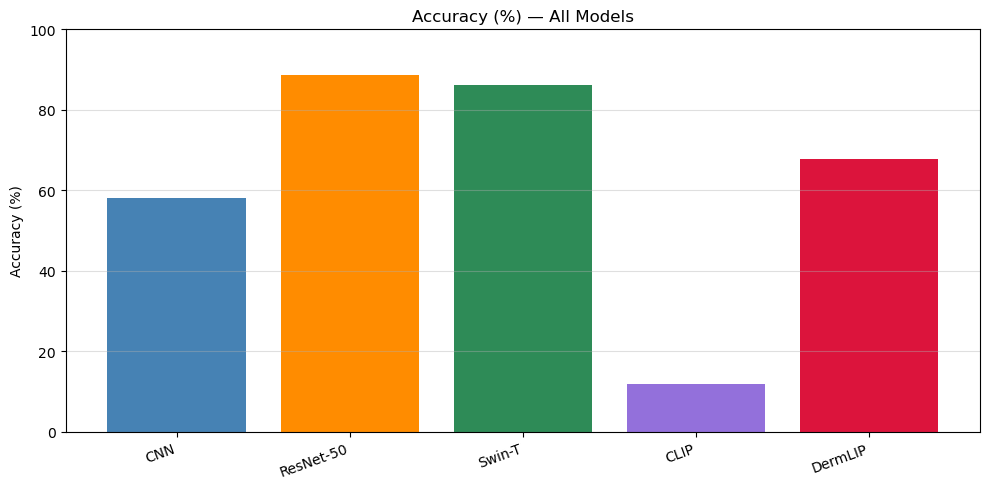

/tmp/ipykernel_1008/3691175039.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')


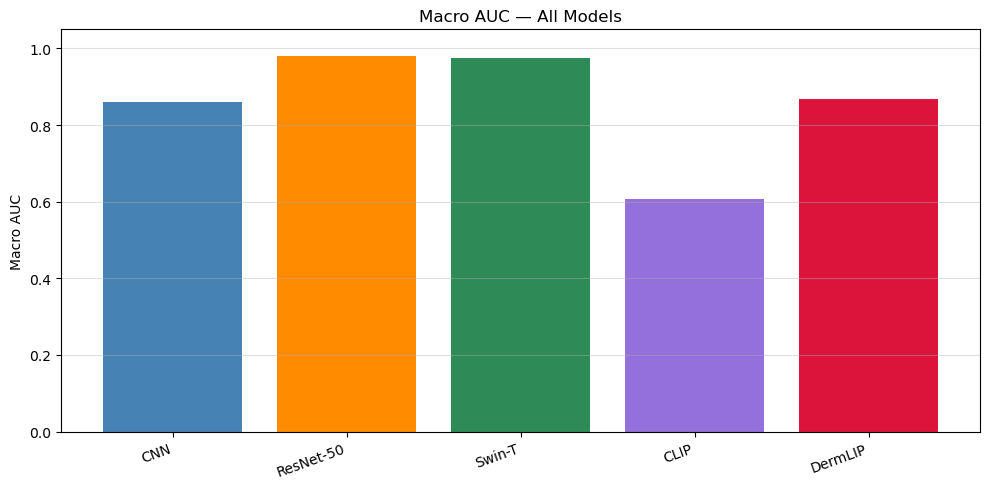

/tmp/ipykernel_1008/3691175039.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')


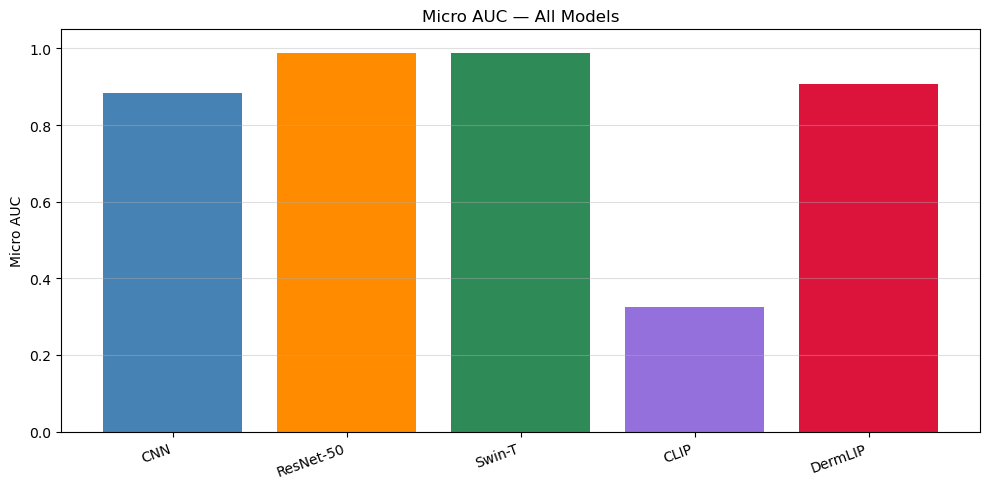

In [6]:
for metric, ylabel in [('accuracy', 'Accuracy (%)'), ('macro_auc', 'Macro AUC'), ('micro_auc', 'Micro AUC')]:
    fig, ax = plt.subplots(figsize=(10, 5))
    vals = [results[m][metric] for m in MODEL_NAMES]
    ax.bar(MODEL_NAMES, vals, color=COLORS)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — All Models')
    ax.set_ylim(0, 100 if metric == 'accuracy' else 1.05)
    ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

---
## Per-class AUC

In [7]:
print(f"{'Class':<25}", end='')
for name in MODEL_NAMES:
    print(f"  {name:>10}", end='')
print()
print('-' * (25 + 12 * len(MODEL_NAMES)))
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<25}", end='')
    for name in MODEL_NAMES:
        print(f"  {results[name]['per_class_auc'][i]:>10.4f}", end='')
    print()

Class                             CNN   ResNet-50      Swin-T        CLIP     DermLIP
-------------------------------------------------------------------------------------
MEL                            0.8516      0.9559      0.9409      0.5937      0.7304
NV                             0.8682      0.9737      0.9667      0.4905      0.8709
BCC                            0.9199      0.9956      0.9951      0.5804      0.9787
AKIEC                          0.9040      0.9670      0.9751      0.7892      0.8800
BKL                            0.7669      0.9655      0.9567      0.6272      0.7227
DF                             0.7394      1.0000      0.9983      0.6335      0.9621
VASC                           0.9681      0.9998      0.9994      0.5406      0.9314


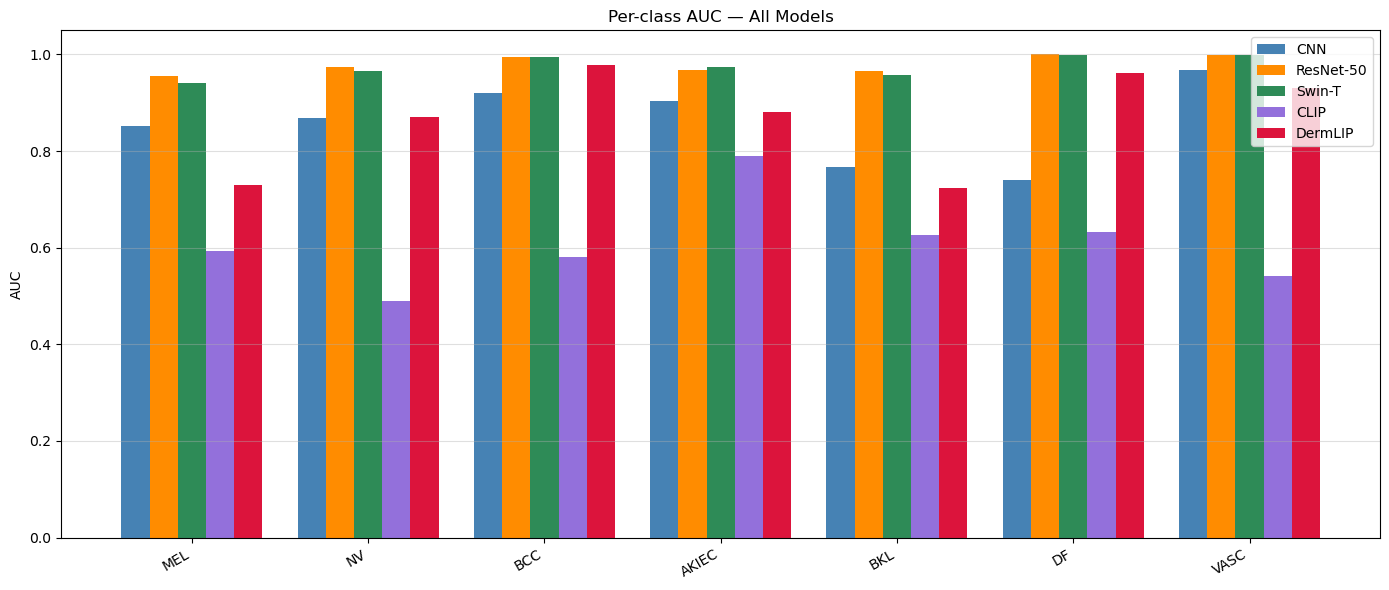

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
    vals = [results[name]['per_class_auc'][j] for j in range(len(CLASS_NAMES))]
    ax.bar(x + i * width - (len(MODEL_NAMES) - 1) * width / 2, vals, width, label=name, color=color)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Per-class AUC — All Models')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Precision / Recall / F1 per Class

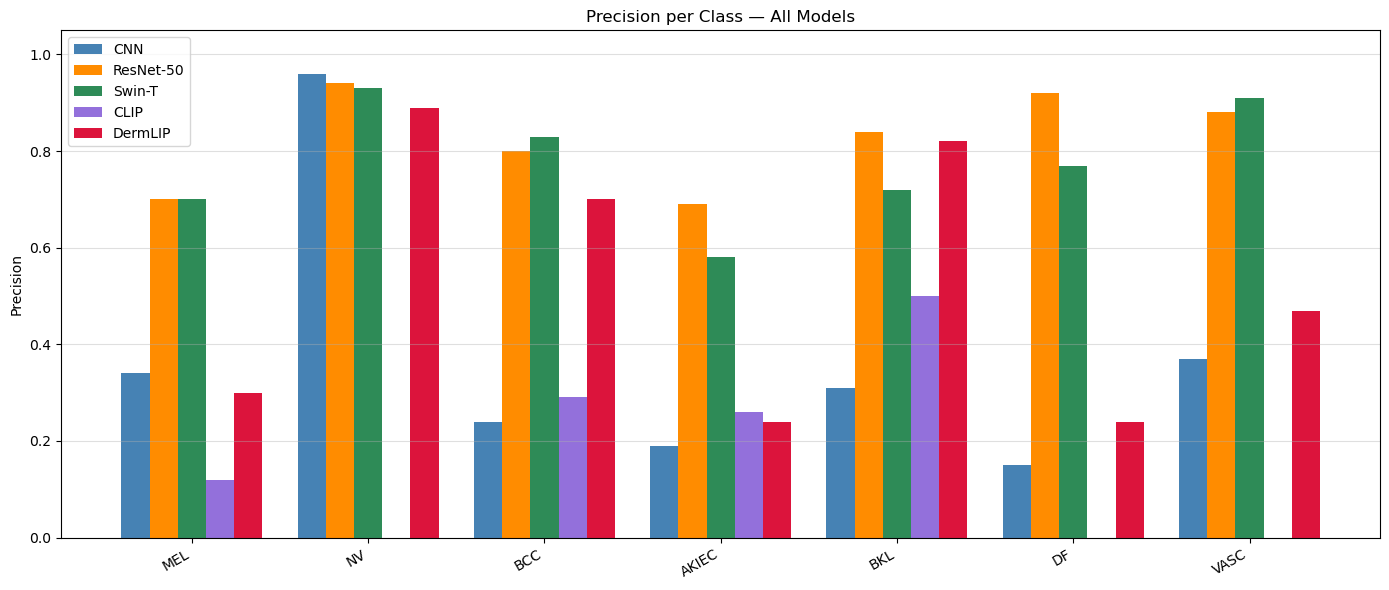

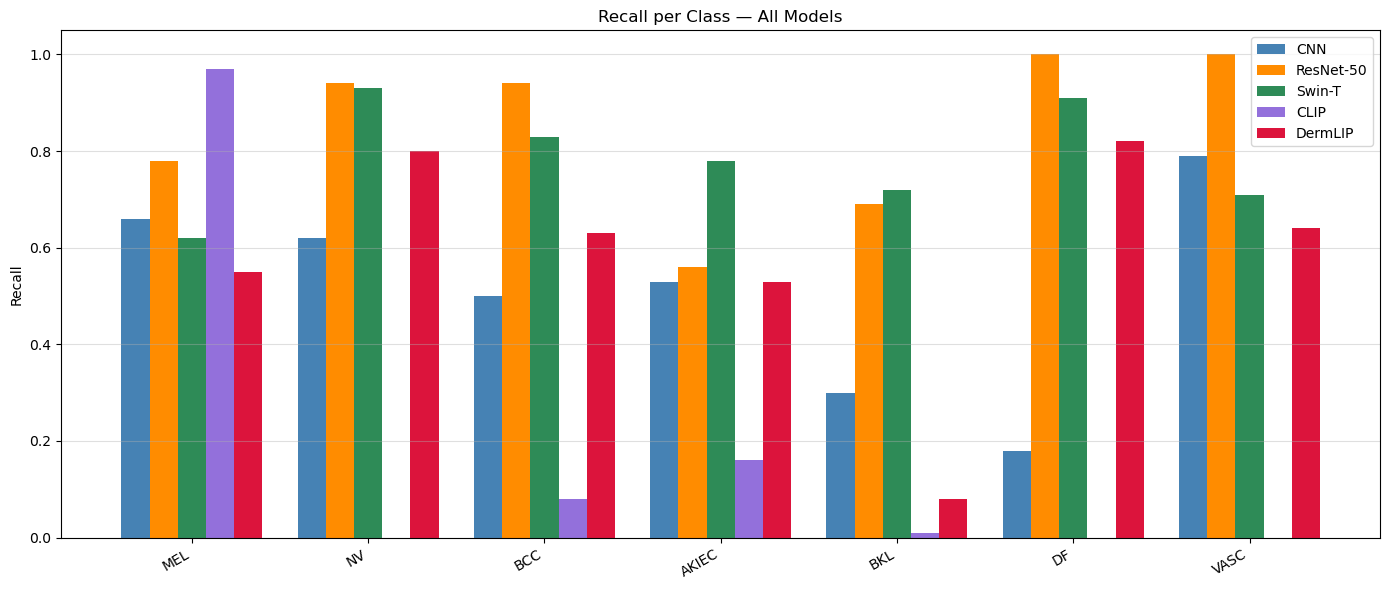

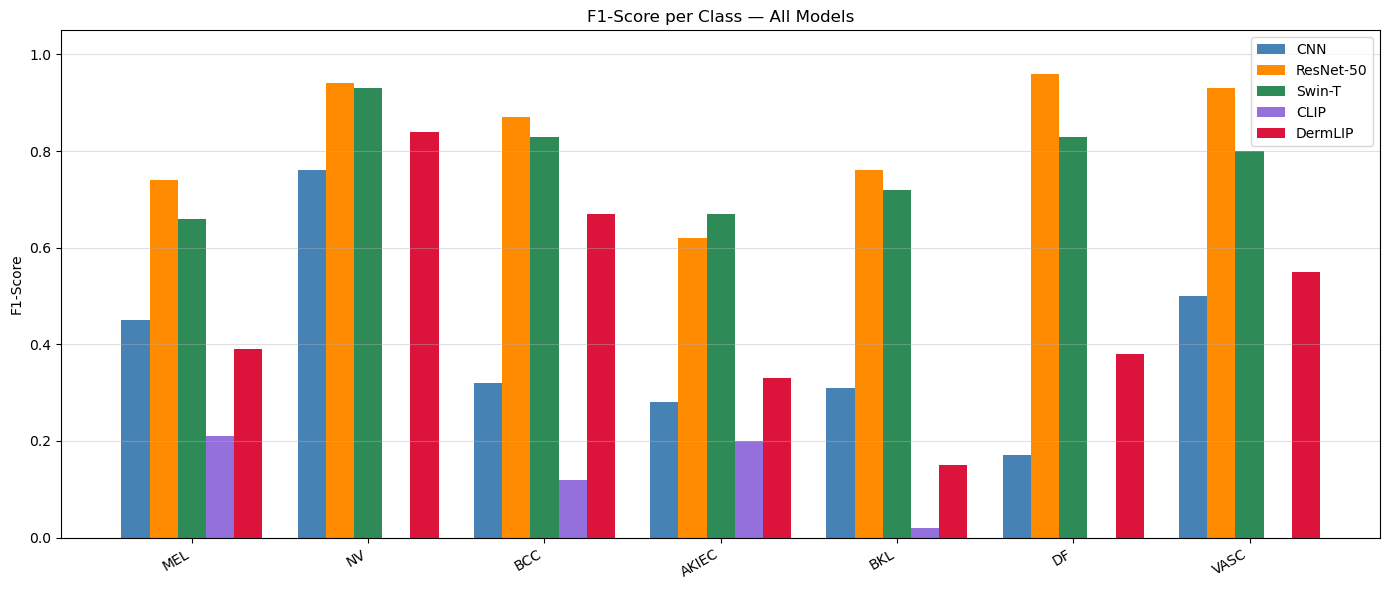

In [9]:
parsed = {name: parse_report(results[name]['report'], CLASS_NAMES) for name in MODEL_NAMES}

for metric, ylabel in [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1-Score')]:
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
        vals = [parsed[name][cls][metric] for cls in CLASS_NAMES]
        ax.bar(x + i * width - (len(MODEL_NAMES) - 1) * width / 2, vals, width, label=name, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} per Class — All Models')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

---
## Confusion Matrices

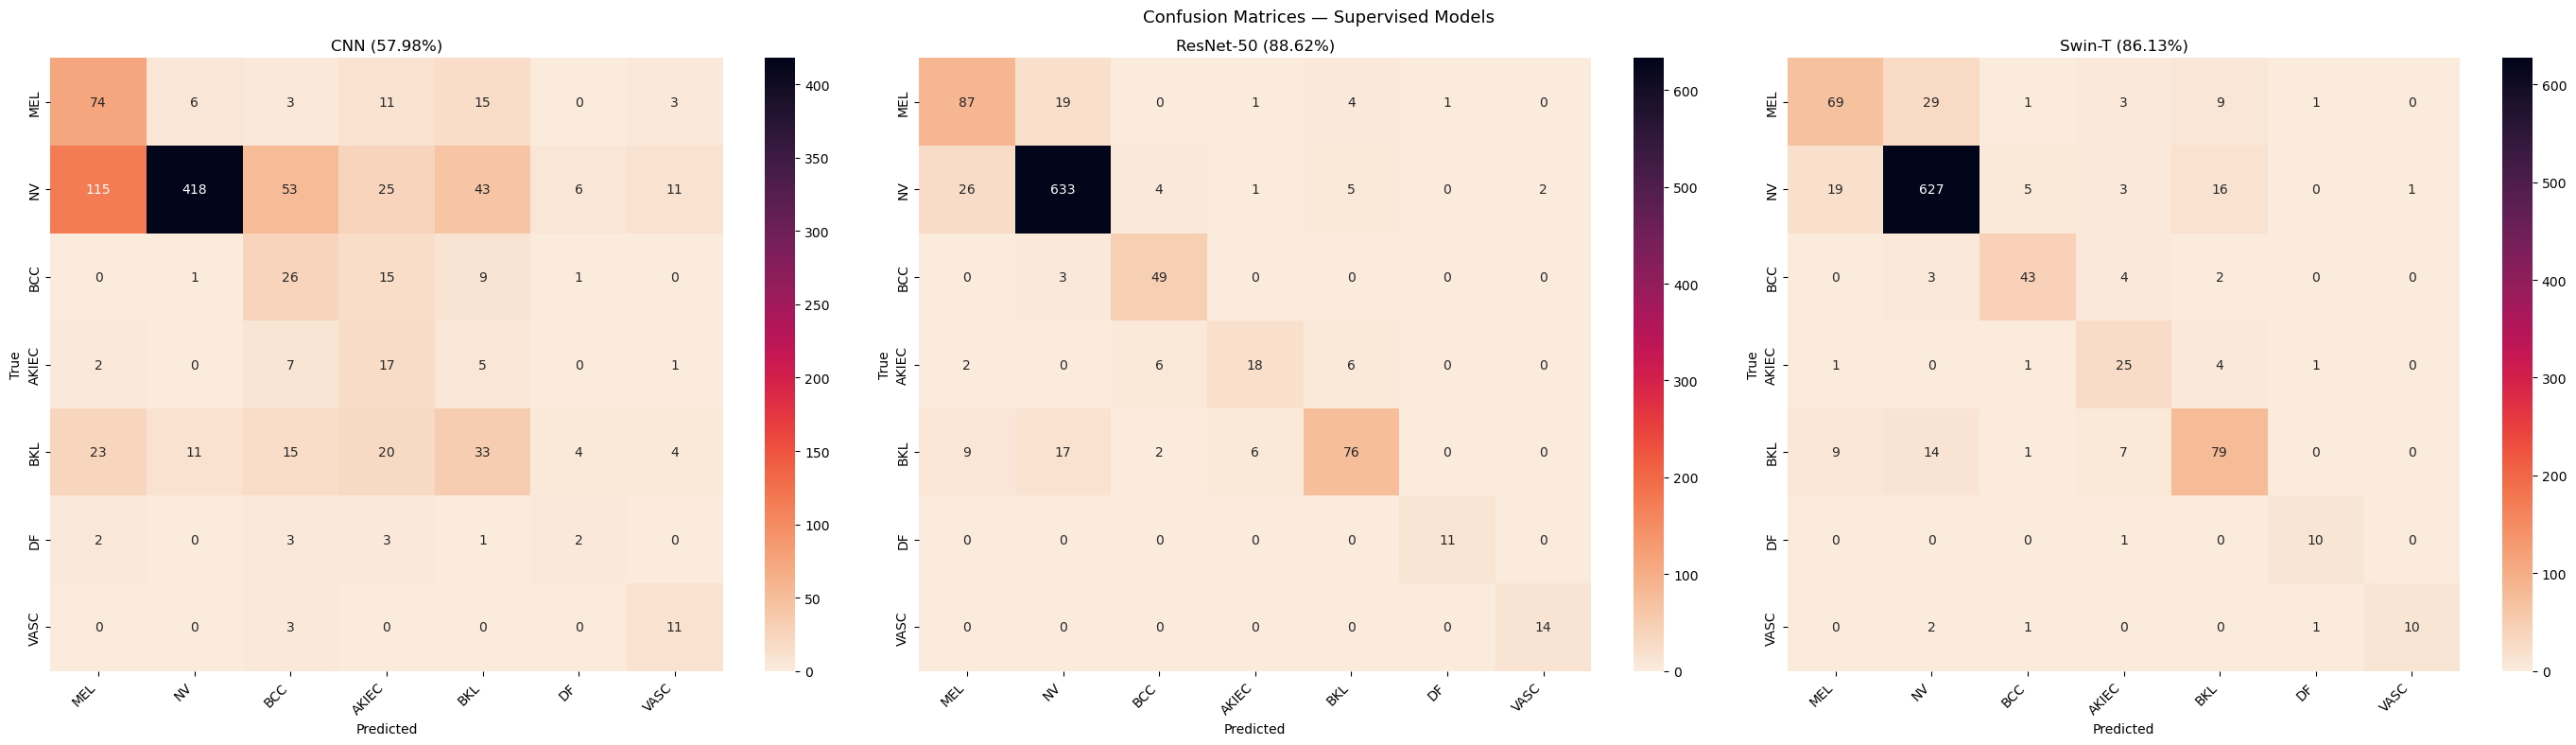

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(28, 8))
for ax, name in zip(axes, ['CNN', 'ResNet-50', 'Swin-T']):
    cm = confusion_matrix(results[name]['labels'], results[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{name} ({results[name]['accuracy']:.2f}%)")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('Confusion Matrices — Supervised Models', fontsize=13)
plt.tight_layout()
plt.show()

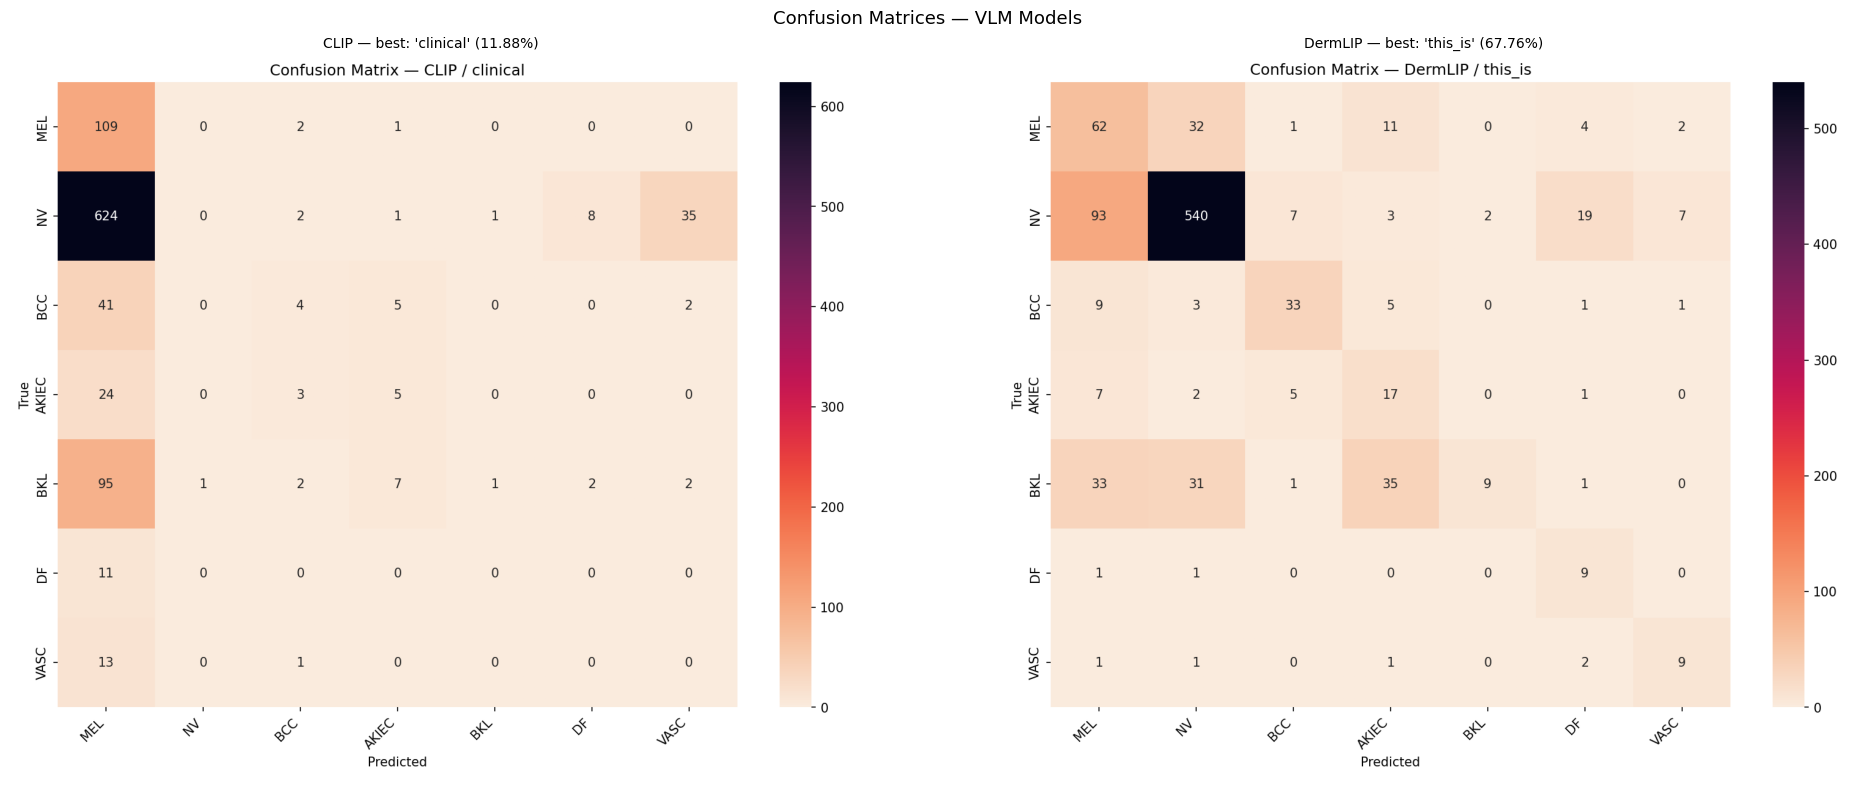

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, name in zip(axes, ['CLIP', 'DermLIP']):
    ax.imshow(mpimg.imread(results[name]['cm_path']))
    ax.set_title(f"{name} — best: '{results[name]['best_template']}' ({results[name]['accuracy']:.2f}%)", fontsize=10)
    ax.axis('off')
plt.suptitle('Confusion Matrices — VLM Models', fontsize=13)
plt.tight_layout()
plt.show()